In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skimage.filters as flt

import sys
import os
from pathlib import Path

sys.path.append("../../src")

import evaluation.io.readers as readers
import evaluation.utils as utils

In [2]:
img = readers.read_image("../../data/mixture12_00001.fits")
mimg = flt.median(img, footprint=np.ones((7, 7)))
diff= img - mimg
med=np.median(img)

In [3]:
mad = np.median(np.abs(img-med))
print(f"MAD: {mad:.2f}")

MAD: 361.00


In [4]:
def mad_outlier_fraction(
    img,
    k=3.0,
    mask=None,
    ignore_nan=True,
    return_z=False,
    eps=1e-12
):
    """
    Compute outlier fraction using MAD-based robust z-score.

    Parameters
    ----------
    img : ndarray
        Input image (2D or 3D).
    k : float
        Threshold for outlier detection (typically 2.5–3.5).
    mask : ndarray (bool), optional
        Boolean mask of valid pixels (True = include).
    ignore_nan : bool
        If True, ignore NaN values.
    return_z : bool
        If True, also return z-score image.
    eps : float
        Small constant to avoid division by zero.

    Returns
    -------
    f_out : float
        Fraction of outliers.
    z : ndarray, optional
        Robust z-score image (if return_z=True).
    """

    x = np.asarray(img)

    # Build valid mask
    valid = np.ones_like(x, dtype=bool)
    if mask is not None:
        valid &= mask
    if ignore_nan:
        valid &= np.isfinite(x)

    x_valid = x[valid]

    if x_valid.size == 0:
        return (np.nan, None) if return_z else np.nan

    med = np.median(x_valid)
    mad = np.median(np.abs(x_valid - med))

    # Avoid division by zero (flat image case)
    mad = max(mad, eps)

    z = np.zeros_like(x, dtype=float)
    z[valid] = 0.6745 * (x[valid] - med) / mad

    # outliers = np.abs(z[valid]) > k
    outliers = z[valid] > k
    f_out = np.mean(outliers)

    if return_z:
        return f_out, z
    else:
        return f_out
    
def local_mad_outlier_fraction(
    img,
    k=3.0,
    footprint=np.ones([7,7]),
    eps=1e-12,
    return_z=False
):
    """
    Compute outlier fraction using MAD-based robust z-score.

    Parameters
    ----------
    img : ndarray
        Input image (2D or 3D).
    k : float
        Threshold for outlier detection (typically 2.5–3.5).
    footprint : int
        Size of the local neighborhood (must be odd).
    eps : float
        Small constant to avoid division by zero.
    return_z : bool
        If True, also return z-score image.

    Returns
    -------
    f_out : float
        Fraction of outliers.
    z : ndarray, optional
        Robust z-score image (if return_z=True).
    """

    x = np.asarray(img)
    med = flt.median(x, footprint=footprint)
    diff = x - med
    mad = np.median(np.abs(diff))

    # Avoid division by zero (flat image case)
    mad = max(mad, eps)

  
    z = 0.6745 * (diff) / mad

    # outliers = np.abs(z) > k
    outliers = z > k
    f_out = np.mean(outliers)

    if return_z:
        return f_out, z
    else:
        return f_out

In [5]:
print(mad_outlier_fraction(img[200:500,200:500], k=3.0, return_z=False),mad_outlier_fraction(mimg[200:500,200:500], k=3.0, return_z=False))

0.007822222222222222 0.002588888888888889


In [6]:
print(local_mad_outlier_fraction(img, k=3.0, return_z=False),local_mad_outlier_fraction(mimg, k=3.0, return_z=False))

0.012786149978637695 0.021059751510620117


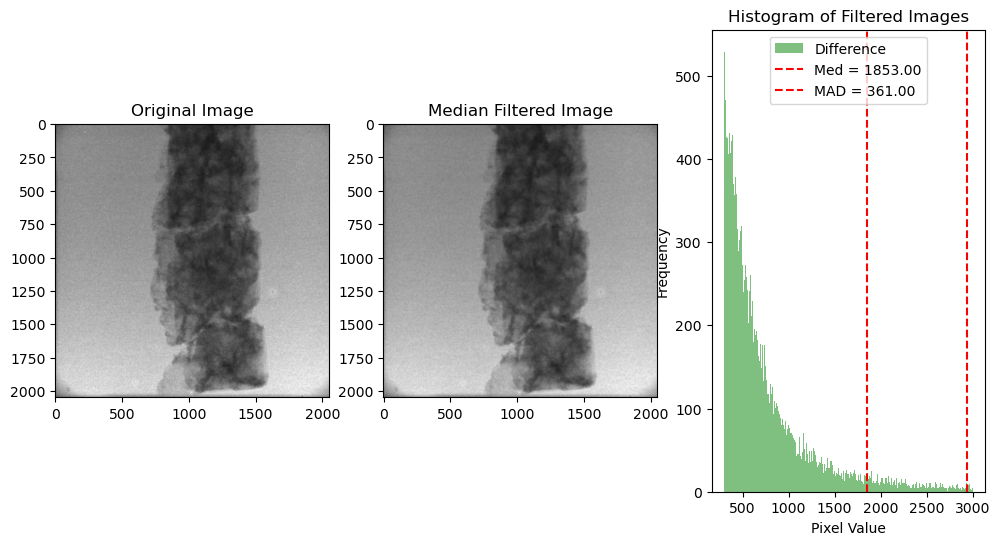

In [7]:



z = 0.6745 * (diff) / mad

fig, ax = plt.subplots(1,3, figsize=(12, 6))

ax[0].imshow(img, cmap="gray", vmin=300, vmax=3000)
ax[0].set_title("Original Image")
ax[1].imshow(mimg, cmap="gray", vmin=300, vmax=3000)
ax[1].set_title("Median Filtered Image")
# ax[2].hist(img.flatten(), bins=250, range=(300, 3000), alpha=0.5, label="Original", color="blue")
# ax[2].hist(mimg.flatten(), bins=250, range=(300, 3000), alpha=0.5, label="Median Filtered", color="orange")
ax[2].hist((diff).ravel(), bins=250, range=(300, 3000), alpha=0.5, label="Difference", color="green")
ax[2].axvline(med, color="red", linestyle="--", label=f"Med = {med:.2f}")
ax[2].axvline(med+3*mad, color="red", linestyle="--", label=f"MAD = {mad:.2f}")
ax[2].set_xlabel("Pixel Value")
ax[2].set_ylabel("Frequency")
ax[2].set_title("Histogram of Filtered Images")
ax[2].legend()



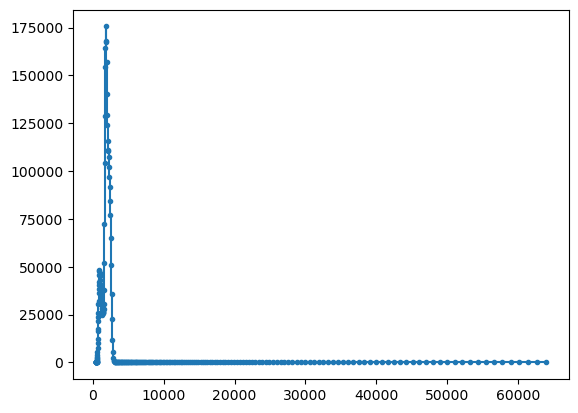

In [17]:
hlog,blog = np.histogram(img.ravel(), bins=np.logspace(np.log10(img.min()), np.log10(img.max()),250))
plt.plot(blog[:-1], hlog, marker='.', drawstyle="steps-mid")

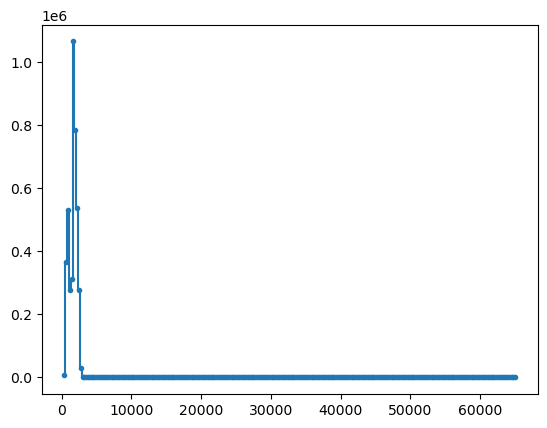

In [18]:
hlin,blin = np.histogram(img.ravel(), bins=np.linspace(img.min(), img.max(), 250))
plt.plot(blin[:-1], hlin, marker='.', drawstyle="steps-mid")

In [19]:
import scipy.stats as stats

print(stats.entropy(hlin/np.sum(hlin)), stats.entropy(hlog/np.sum(hlog)))

2.0110868792231544 4.011894773021622


In [20]:
print(stats.skew(hlin), stats.skew(hlog))
print(stats.kurtosis(hlin), stats.kurtosis(hlog))

7.311844103412055 2.6567573531696884
58.92689325533138 6.709257298613691


In [22]:
print(stats.kurtosis(img.ravel()), stats.kurtosis(mimg.ravel()))
print(stats.skew(img.ravel()), stats.skew(mimg.ravel()))

117.27282 -0.88813376
1.0193086 -0.3511219


In [23]:
print(stats.kurtosis(img.ravel()), stats.kurtosis(mimg.ravel()))

117.27282 -0.88813376


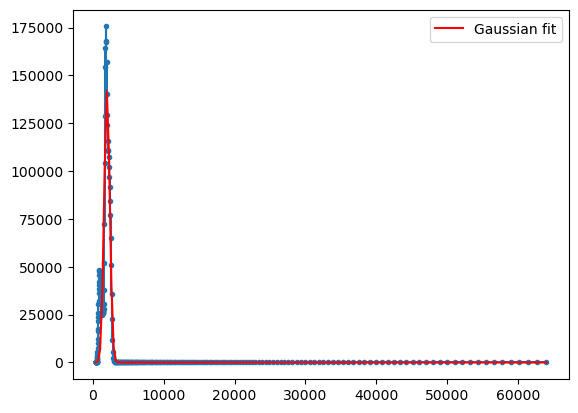

In [31]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Assuming you have: bin_centers (x values) and counts (y values)
popt, pcov = curve_fit(gaussian, blog[:-1], hlog, p0=[hlog.max(), np.mean(blog), np.std(blog)])
amp, mu, sigma = popt

# Plot
plt.plot(blog[:-1], hlog, marker='.', drawstyle="steps-mid")

x_fit = np.linspace(blog[:-1].min(), blog[:-1].max(), 200)
plt.plot(x_fit, gaussian(x_fit, *popt), 'r-', label=f'Gaussian fit')
plt.legend()
plt.show()

In [32]:
popt

array([141981.03544941,   2010.09055863,    394.389774  ])

In [52]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

def fitted_outlier_fraction(
    img,
    k=3.0,
    footprint=np.ones([7,7]),
    eps=1e-12,
    return_z=False
):
    x = np.asarray(img)

    hlog,blog = np.histogram(x.ravel(), bins=np.logspace(np.log10(np.maximum(x.min(),1)), np.log10(x.max()),250))

    h_bad_count = (~np.isfinite(hlog)).sum()
    b_bad_count = (~np.isfinite(blog)).sum()
    print("NaN or Inf:", h_bad_count , b_bad_count)

    popt, pcov = curve_fit(gaussian, blog[:-1], hlog, p0=[hlog.max(), np.mean(blog), np.std(blog)])
    amp, mu, sigma = popt
    

    outliers = x > mu+k*sigma
    f_out = np.mean(outliers)

    if return_z:
        return f_out, z
    else:
        return f_out

In [53]:
print(fitted_outlier_fraction(diff, k=3.0, return_z=False), fitted_outlier_fraction(mimg, k=3.0, return_z=False))

NaN or Inf: 0 0
NaN or Inf: 0 0
0.012520790100097656 0.0
